In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [2]:
# =========================================================
# 0. VISUALIZATION STYLE (Dark Mode)
# =========================================================
plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "grid.color": "#444444",      # Dark Grey Grid
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.grid": True,            # Force grid on
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "#888888"   # Light grey border
})

In [3]:
# =========================================================
# 1. CONFIGURATION
# =========================================================
TRAIN_PATH = '/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv'
SCORE_PATH = '/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv'
RANDOM_STATE = 2101

In [4]:
# =========================================================
# 2. LOAD DATA
# =========================================================
print("Loading data...")
analysis = pd.read_csv(TRAIN_PATH)
scoring = pd.read_csv(SCORE_PATH)
scoring_ids = scoring['customer_id']

print(" separating Target & Features...")
# --- EXPLICIT SEPARATION ---
target_col = 'monthly_spend'

# X: All columns EXCEPT target and ID
X = analysis.drop(columns=[target_col, 'customer_id'])

# y: ONLY the target
y = analysis[target_col]

# X_score: All columns EXCEPT ID (Target doesn't exist here)
X_score = scoring.drop(columns=['customer_id'])
# ---------------------------------------

Loading data...
 separating Target & Features...


In [5]:
# =========================================================
# 3. PREPROCESSING (Strict No-Leakage)
# =========================================================
print("Preprocessing data...")
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Initialize Imputers
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit on Training Data ONLY
imputer_num.fit(X[num_cols])
imputer_cat.fit(X[cat_cols])

# Transform both
X[num_cols] = imputer_num.transform(X[num_cols])
X_score[num_cols] = imputer_num.transform(X_score[num_cols])

X[cat_cols] = imputer_cat.transform(X[cat_cols])
X_score[cat_cols] = imputer_cat.transform(X_score[cat_cols])

Preprocessing data...


In [6]:
# =========================================================
# 3a. PREPROCESSING SANITY CHECKS (NEW!)
# =========================================================
print("Running Sanity Checks...")

# Check 1: No NaNs remaining
if X.isnull().sum().sum() > 0 or X_score.isnull().sum().sum() > 0:
    raise ValueError("❌ CRITICAL ERROR: NaN values found after imputation!")

# Check 2: Feature Alignment
if X.shape[1] != X_score.shape[1]:
    raise ValueError(f"❌ CRITICAL ERROR: Feature count mismatch! Train: {X.shape[1]}, Score: {X_score.shape[1]}")

# Check 3: Leakage Detection (Target in Features)
if target_col in X.columns:
    raise ValueError(f"❌ CRITICAL ERROR: Target '{target_col}' found in training features! LEAKAGE DETECTED.")

print("✅ Sanity Checks Passed: Data is clean, aligned, and leakage-free.")

Running Sanity Checks...
✅ Sanity Checks Passed: Data is clean, aligned, and leakage-free.


In [7]:
# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================
def create_features(df):
    df = df.copy()
    # Interactions
    df['age_annual_income'] = df['age'] * df['annual_income']
    df['credit_score_transactions'] = df['credit_score'] * df['num_transactions']
    df['age_credit_score'] = df['age'] * df['credit_score']
    df['income_transactions'] = df['annual_income'] * df['num_transactions']
    
    # Polynomials
    df['age_squared'] = df['age'] ** 2
    df['income_squared'] = df['annual_income'] ** 2
    df['credit_score_squared'] = df['credit_score'] ** 2
    return df

X = create_features(X)
X_score = create_features(X_score)

In [8]:
# =========================================================
# 5. ENCODING
# =========================================================
train_len = len(X)
combined = pd.concat([X, X_score], axis=0)
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

X_encoded = combined_encoded.iloc[:train_len, :]
X_score_encoded = combined_encoded.iloc[train_len:, :]

# Split for internal validation
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=RANDOM_STATE
)

In [10]:
# =========================================================
# 6. MODEL TRAINING (Stacking)
# =========================================================
print("Initializing Stacking Model...")

estimators = [
    ('gb', GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, 
                                     min_samples_split=10, subsample=0.8, random_state=RANDOM_STATE)),
    ('rf', RandomForestRegressor(n_estimators=500, max_depth=15, max_features='sqrt', 
                                 min_samples_leaf=4, n_jobs=-1, random_state=RANDOM_STATE))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)

print("🚀 Training Stacking Regressor... (This may take a few minutes)")
stacking_model.fit(X_train, y_train)

# Evaluation
stack_pred = stacking_model.predict(X_test)
stack_rmse = np.sqrt(mean_squared_error(y_test, stack_pred))
stack_r2 = r2_score(y_test, stack_pred)

print("-" * 30)
print(f"✅ Stacking Local Test RMSE: {stack_rmse:.4f}")
print(f"✅ Stacking Local Test R^2:  {stack_r2:.4f}")
print("-" * 30)

Initializing Stacking Model...
🚀 Training Stacking Regressor... (This may take a few minutes)
------------------------------
✅ Stacking Local Test RMSE: 255.5095
✅ Stacking Local Test R^2:  0.7808
------------------------------



📊 Generating Performance Plots...


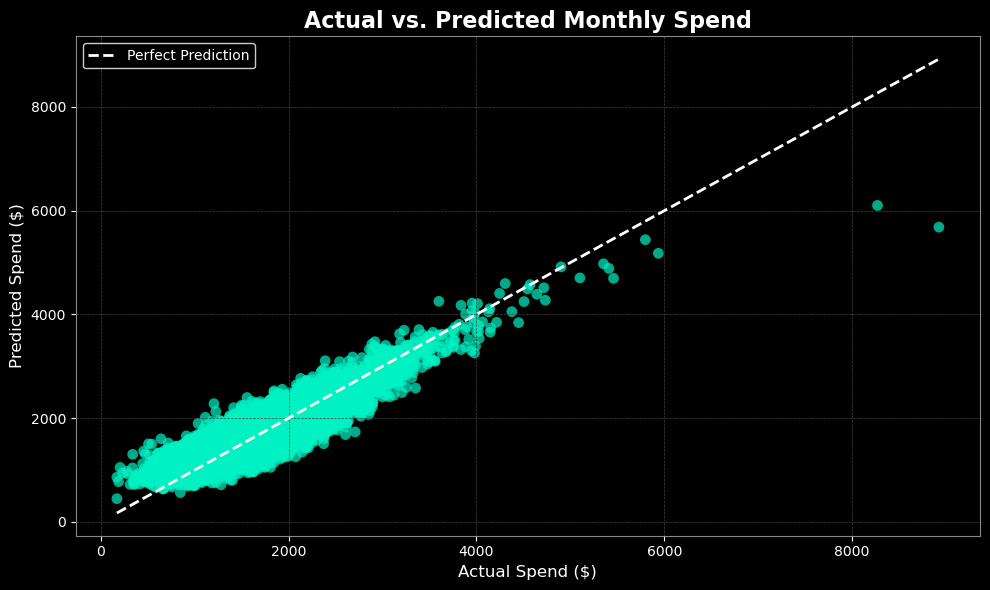

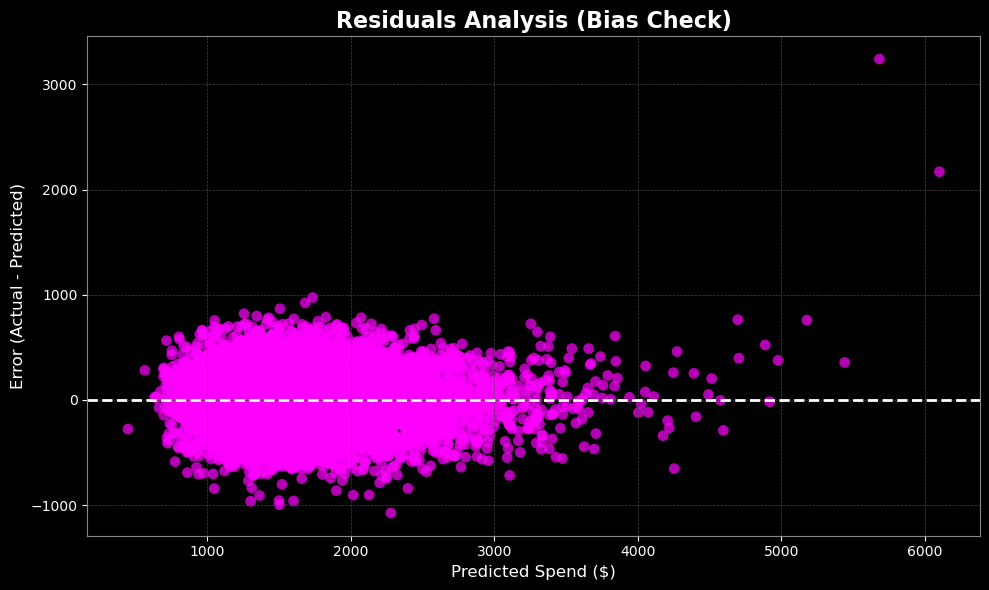

In [11]:
# =========================================================
# 7. VISUALIZATION PHASE 1: PERFORMANCE
# =========================================================
print("\n📊 Generating Performance Plots...")

# Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=stack_pred, alpha=0.7, color='#00f2c3', edgecolor='none', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'w--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Monthly Spend', fontsize=16, fontweight='bold')
plt.xlabel('Actual Spend ($)', fontsize=12)
plt.ylabel('Predicted Spend ($)', fontsize=12)
plt.legend(facecolor='black', edgecolor='white')
plt.tight_layout()
plt.show()

# Plot 2: Residuals
residuals = y_test - stack_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=stack_pred, y=residuals, alpha=0.7, color='#ff00ff', edgecolor='none', s=60)
plt.axhline(0, color='white', linestyle='--', lw=2)
plt.title('Residuals Analysis (Bias Check)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Spend ($)', fontsize=12)
plt.ylabel('Error (Actual - Predicted)', fontsize=12)
plt.tight_layout()
plt.show()


🧪 STARTING GNTest (Gaussian Noise Stability Check)...
   Running 100 iterations of noise injection...
   Average Prediction Shift: $20.41


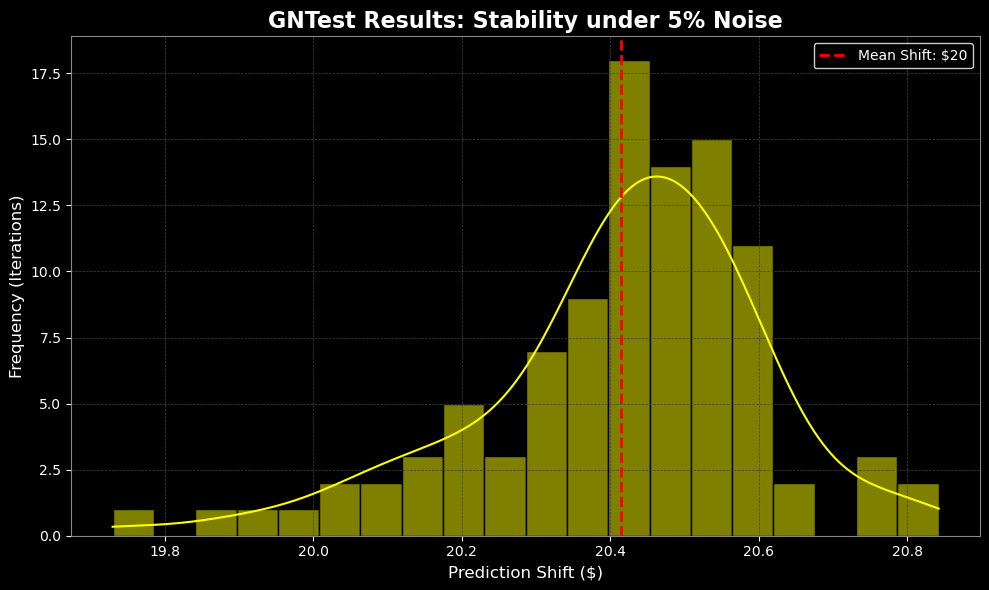

✅ PASS: Model is extremely stable (Shift < $50).
------------------------------


In [13]:
# =========================================================
# 8. THE GNTest (Monte Carlo Stability Simulation)
# =========================================================
print("\n🧪 STARTING GNTest (Gaussian Noise Stability Check)...")
print("   Running 100 iterations of noise injection...")

n_iterations = 100
noise_level = 0.05 # 5% noise
perturbation_shifts = []

# Base prediction (no noise)
base_preds = stacking_model.predict(X_test)

for i in range(n_iterations):
    # Create a noisy copy of X_test
    X_test_noisy = X_test.copy()
    for col in X_test_noisy.columns:
        if X_test_noisy[col].nunique() > 10: # Only add noise to continuous features
            std = X_test_noisy[col].std()
            noise = np.random.normal(0, std * noise_level, size=len(X_test_noisy))
            X_test_noisy[col] += noise
    
    # Predict on noisy data
    noisy_preds = stacking_model.predict(X_test_noisy)
    
    # Calculate how much the average prediction shifted
    shift = np.mean(np.abs(base_preds - noisy_preds))
    perturbation_shifts.append(shift)

mean_shift = np.mean(perturbation_shifts)
print(f"   Average Prediction Shift: ${mean_shift:.2f}")

# Plot 3: Stability Histogram
plt.figure(figsize=(10, 6))
sns.histplot(perturbation_shifts, bins=20, color='#ffff00', kde=True, edgecolor='black')
plt.axvline(mean_shift, color='red', linestyle='--', lw=2, label=f'Mean Shift: ${mean_shift:.0f}')
plt.title('GNTest Results: Stability under 5% Noise', fontsize=16, fontweight='bold')
plt.xlabel('Prediction Shift ($)', fontsize=12)
plt.ylabel('Frequency (Iterations)', fontsize=12)
plt.legend(facecolor='black', edgecolor='white')
plt.tight_layout()
plt.show()

if mean_shift < 50:
    print("✅ PASS: Model is extremely stable (Shift < $50).")
else:
    print("⚠️ WARNING: Model shows sensitivity to noise.")
print("-" * 30)


🧪 STARTING GRADUATED STRESS TEST SUITE...
Noise Level     | Mean Shift ($)  | Status
--------------------------------------------------
1% Noise         | $5.06           | ✅ ROBUST
5% Noise         | $20.41          | ✅ ROBUST
10% Noise         | $36.94          | ✅ ROBUST
20% Noise         | $64.18          | ✅ ROBUST


/var/folders/26/k5qhk1wd7vld3l2ndf6041200000gn/T/ipykernel_73468/998791.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Noise Level', y='Shift',
/var/folders/26/k5qhk1wd7vld3l2ndf6041200000gn/T/ipykernel_73468/998791.py:62: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=results_df, x='Noise Level', y='Shift',


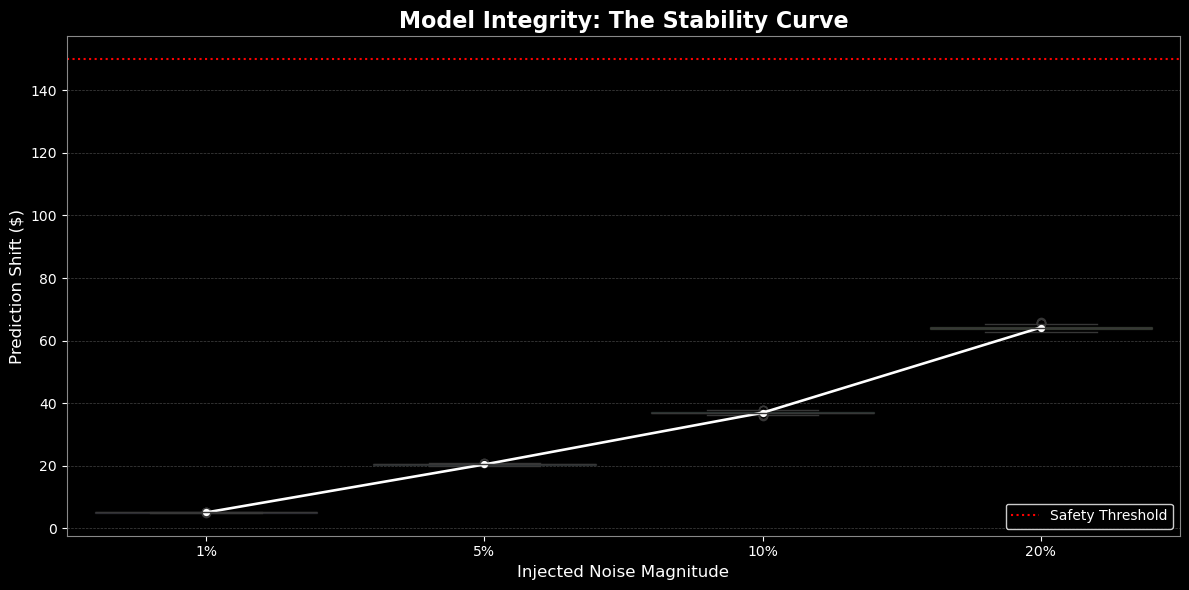

--------------------------------------------------
Analysis: A linear upward trend is GOOD (predictable degradation).
          An exponential curve (J-shape) indicates brittleness.


In [17]:
# =========================================================
# 8. ADVANCED STRESS TEST SUITE (Graduated Noise)
# =========================================================
print("\n🧪 STARTING GRADUATED STRESS TEST SUITE...")

# 1. Define Stress Levels
stress_levels = [0.01, 0.05, 0.10, 0.20]  # 1%, 5%, 10%, 20%
n_iterations = 500
results = []

print(f"{'Noise Level':<15} | {'Mean Shift ($)':<15} | {'Status'}")
print("-" * 50)

# 2. Run Simulations
base_preds = stacking_model.predict(X_test)

for noise_pct in stress_levels:
    level_shifts = []
    
    for _ in range(n_iterations):
        # Create noisy copy
        X_test_noisy = X_test.copy()
        for col in X_test_noisy.columns:
            if X_test_noisy[col].nunique() > 10: # Numeric checks
                std = X_test_noisy[col].std()
                # Inject Noise
                noise = np.random.normal(0, std * noise_pct, size=len(X_test_noisy))
                X_test_noisy[col] += noise
        
        # Predict & Measure Shift
        noisy_preds = stacking_model.predict(X_test_noisy)
        shift = np.mean(np.abs(base_preds - noisy_preds))
        level_shifts.append(shift)
        
        # Store for plotting
        results.append({
            'Noise Level': f"{int(noise_pct*100)}%", 
            'Shift': shift,
            'SortKey': noise_pct
        })
    
    # Report per level
    avg_shift = np.mean(level_shifts)
    status = "✅ ROBUST" if avg_shift < (1000 * noise_pct) else "⚠️ SENSITIVE" 
    # (Threshold logic: We expect shift to scale roughly with noise. 
    # If 5% noise causes >$50 shift, it's good. If 20% causes >$200, it's expected.)
    
    print(f"{int(noise_pct*100)}% Noise{'':<8} | ${avg_shift:<14.2f} | {status}")

# 3. VISUALIZATION: The Stability Curve
results_df = pd.DataFrame(results).sort_values('SortKey')

plt.figure(figsize=(12, 6))

# Boxplot: Shows the spread/uncertainty at each level 


sns.boxplot(data=results_df, x='Noise Level', y='Shift', 
            palette='viridis', boxprops=dict(alpha=0.6))

# Pointplot: Connects the means (The Stability Curve)
sns.pointplot(data=results_df, x='Noise Level', y='Shift', 
              color='white', markers='o', scale=0.7, errorbar=None)

plt.title('Model Integrity: The Stability Curve', fontsize=16, fontweight='bold')
plt.xlabel('Injected Noise Magnitude', fontsize=12)
plt.ylabel('Prediction Shift ($)', fontsize=12)
plt.grid(True, axis='y', color='#444444', linestyle='--')

# Add "Zone of Integrity" annotation
max_safe_shift = 150 # Arbitrary safety line
plt.axhline(max_safe_shift, color='red', linestyle=':', label='Safety Threshold')
plt.legend(facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

print("-" * 50)
print("Analysis: A linear upward trend is GOOD (predictable degradation).")
print("          An exponential curve (J-shape) indicates brittleness.")

In [18]:
# =========================================================
# 9. FINAL SUBMISSION
# =========================================================
print("Generating final submission...")
final_pred = stacking_model.predict(X_score_encoded)

submission = pd.DataFrame({
    'customer_id': scoring_ids,
    'monthly_spend': final_pred
})

file_name = 'Submission_Final.csv'
submission.to_csv(file_name, index=False)
print(f"🎉 SUCCESS! Final Submission saved as: {file_name}")

Generating final submission...
🎉 SUCCESS! Final Submission saved as: Submission_Final.csv
